In [1]:
#| default_exp models.arima

In [2]:
#| export
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union
import numpy as np
import pandas as pd
import copy
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from peshbeen.transformations import (box_cox_transform, back_box_cox_transform,
                                      rolling_quantile,
                        expanding_mean, expanding_std, expanding_quantile)
from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
# dot not show warnings
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsforecast.models import ARIMA
from sklearn.compose import ColumnTransformer

class arima:

    def __init__(
        self,
        target_col: str,
        order: Optional[Tuple[int, int, int]] = (0, 0, 0),
        seasonal_order: Optional[Tuple[int, int, int]] = (0, 0, 0),
        seasonal_length: Optional[int] = 1,
        lag_transform: Optional[list] = None,
        trend: Optional[str] = None,
        pol_degree: int = 1,
        ets_params: Optional[Dict[str, Any]] = None,
        change_points: Optional[List[int]] = None,
        box_cox: Union[bool, float, int] = False,
        box_cox_biasadj: bool = False,
        cat_variables: Optional[List[str]] = None,
        categorical_encoder: Optional[Any] = None,
        target_encode: bool = False) -> None:

        """
        Initialize the arima model with the specified parameters and configurations.

        Parameters
        ----------
        target_col : str
            Name of the target variable column in the input DataFrame.
        order : tuple of int, optional
            The (p, d, q) order of the ARIMA model. Default is (0, 0, 0).
        seasonal_order : tuple of int, optional
            The (P, D, Q) order of the seasonal ARIMA model. Default is (0, 0, 0).
        seasonal_length : int, optional
            The seasonal period for the seasonal ARIMA model. Default is 1.
        lag_transform : list of function objects, optional
            List of lag-transform function objects to apply to the target variable (e.g. [expanding_mean(shift=1), rolling_std(window_size=3, shift=1)]). Each function should take a pandas Series as input and return a Series of the same length. Default is None (no lag transforms).
        trend : str, optional
            Trend strategy to use. Options are 'linear' for linear trend removal, 'ets' for ETS-based trend removal, 'feature_lr' for using linear trend components as features, and 'feature_ets' for using ETS trend components as features. Default is None (no trend handling).
        pol_degree : int, optional
            Degree of polynomial trend to fit when using 'linear' or 'feature_lr' trend strategy. Default is 1 (linear trend).
        ets_params : Dict[str, Any], optional
            Dictionary of parameters for the ExponentialSmoothing model when using 'ets' trend strategy. The keys should be the parameter names and the values should be the parameter values. Default is None (use default ETS parameters).
        change_points : list of int, optional
            List of indices in the time series where change points occur for piecewise linear trend fitting. Only used when trend strategy is 'linear' or 'feature_lr'. Default is None (no change points, fit a single linear trend).
        box_cox : bool or float or int, optional
            Whether to apply Box-Cox transformation to the target variable. If a float or int value is provided, it will be used as the lambda parameter for the Box-Cox transformation. If True, the lambda parameter will be estimated from the data.
        box_cox_biasadj : bool, optional
            Whether to apply bias adjustment when inverting the Box-Cox transformation on forecasts. Default is False.
        cat_variables : list of str, optional
            List of categorical feature column names. If provided, these columns will be treated as categorical variables and encoded accordingly. Default is None (no categorical variables).
        categorical_encoder : object, optional
            Categorical encoder object (e.g. OneHotEncoder(), MeanEncoder(), etc.) to apply to the categorical variables specified in cat_variables. The encoder should have fit() and transform() methods that can be applied to the input DataFrame. Default is None (no categorical encoding) and if None, categorical variables can only be used if the model can handle them natively (e.g. LGBM or CatBoost).

        Returns
        -------
        None
        """
        
        self.target_col = target_col
        self.cat_variables = cat_variables
        self.cat_encoder = categorical_encoder
        self.target_encode = target_encode
        self.cps = change_points
        self.pol = pol_degree
        if isinstance(box_cox, bool):
            self.box_cox = box_cox
            self.lamda = None
        elif isinstance(box_cox, (float, int)):
            self.box_cox = True
            self.lamda = box_cox
        self.biasadj = box_cox_biasadj
        self.order = order
        self.seasonal_order = seasonal_order
        self.seasonal_length = seasonal_length
        self.lag_transform = lag_transform

        # ── trend ─────────────────────────────────────────────────────────────
        self.trend = trend
        if self.trend == "ets":
            self.ets_model = {}
            self.ets_fit = {}
            if ets_params is not None:
                # make sure ets_params is a dict with keys for both constructor and fit params
                if not isinstance(ets_params, dict):
                    raise TypeError("ets_params must be a dictionary with keys for both constructor and/or fit parameters.")
                # ExponentialSmoothing constructor params
                constructor_params = ["trend","damped_trend", "seasonal","seasonal_periods","initialization_method",
                                      "initial_level","initial_trend", "initial_seasonal","bounds","dates","freq","missing"]

                # ExponentialSmoothing.fit params
                fit_params = ["optimized","smoothing_level","smoothing_trend","smoothing_seasonal","damping_trend",
                    "remove_bias","start_params","method","minimize_kwargs","use_brute"]
                for param in constructor_params:
                    if param in ets_params:
                        self.ets_model[param] = ets_params[param]
                for param in fit_params:
                    if param in ets_params:
                        self.ets_fit[param] = ets_params[param]

        # ── placeholders set during fit ───────────────────────────────────────
        self.tuned_params = None
        self.actuals = None
        self.prob_forecasts = None

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────

    def data_prep(self,
                  df: pd.DataFrame) -> pd.DataFrame:
        """
        Prepare the data for modeling by applying the specified transformations and feature engineering steps.

        Parameters
        ----------
        df : pd.DataFrame
            Input DataFrame containing the target and any feature columns.
        """
        dfc = df.copy()

        # ── categorical encoding ──────────────────────────────────────────────
        if self.cat_variables is not None:
            dfc = self.create_encoded_features(dfc)

        if self.target_col not in dfc.columns:
            return dfc.dropna()
        
        self.orig_target = dfc[self.target_col].values # store for generating in sample residuals later
        # ── Box-Cox ───────────────────────────────────────────────────────────
        if self.box_cox:
            self.is_zero = np.any(np.array(dfc[self.target_col]) < 1)
            self.trans_data, self.lamda = box_cox_transform(
                x=dfc[self.target_col], shift=self.is_zero, box_cox_lmda=self.lamda
            )
            dfc[self.target_col] = self.trans_data

        # ── Trend removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.target_orig = dfc[self.target_col].copy()

            if self.trend == "linear":
                if self.cps is not None:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol,
                        breakpoints=self.cps, type='piecewise'
                    )
                else:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol
                    )

            elif self.trend == "ets":
                self.ets_model_fit = ExponentialSmoothing(
                    dfc[self.target_col], **self.ets_model
                ).fit(**self.ets_fit)
                self.trend_vals = self.ets_model_fit.fittedvalues.values

            else:
                raise ValueError(
                    f"Unknown trend type '{self.trend}'. "
                    "Use 'linear' or 'ets'."
                )
            
            dfc[self.target_col] = dfc[self.target_col] - self.trend_vals

        # ── Lag transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for func in self.lag_transform:
                if isinstance(func, (expanding_std, expanding_mean)):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[self.target_col])
                elif isinstance(func, expanding_quantile):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                elif isinstance(func, rolling_quantile):
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                else:
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[self.target_col])

        return dfc.dropna()
    
    # ─────────────────────────────────────────────────────────────────────────
    # ENCODE CATEGORICAL FEATURES
    # ─────────────────────────────────────────────────────────────────────────

    def create_encoded_features(self,
                    df: pd.DataFrame
                    ) -> pd.DataFrame:
        
        ## make sure categorical variables are treated as category dtype for encoding
        for col in self.cat_variables:
            df[col] = df[col].astype('category')
        ## if fit has been called but forecat has not been called yet, we can fit the encoder on the training data and store it for use during forecasting

        if self.cat_encoder is not None:
            # if self.target_col in df.columns and not hasattr(self, "model_fit"):
            if self.target_col in df.columns: # if we have target values, we are in the fit stage and can fit the encoder on the training data (if not already fitted) and then transform the data for model fitting
                num_cols = [c for c in df.columns if c not in self.cat_variables + [self.target_col]]

                # pass_cols = self.cat_variables + num_cols
                self.preprocess = ColumnTransformer(
                    transformers=[("cat", self.cat_encoder, self.cat_variables), ("num", "passthrough", num_cols)],
                    remainder="drop",
                    verbose_feature_names_out=False
                ).set_output(transform="pandas")

                X_train = self.preprocess.fit_transform(df.drop(columns=[self.target_col]), y=df[self.target_col])
                return pd.concat([df[[self.target_col]], X_train], axis=1)
            
            else: # if we do not have target values, we are in the forecast stage and can just transform the data using the already fitted encoder
                return self.preprocess.transform(df)
        else:
            raise ValueError("cat_variables specified but categorical_encoder is None. Please provide a categorical encoder or set cat_variables to None.")

    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────

    def fit(self,
            df: pd.DataFrame
            ) -> None:
        """
        Fit the model to the training data by applying the specified data preparation steps and then fitting the ARIMA model.

        Parameters
        ----------
        df : pd.DataFrame
            Training DataFrame containing the target and any feature columns.
        """

        model_df = self.data_prep(df)
        self.X = model_df.drop(columns=[self.target_col]).to_numpy(dtype=np.float64)
        self.y = model_df[self.target_col].to_numpy()

        self.model = ARIMA(order=self.order, seasonal_order=self.seasonal_order, season_length= self.seasonal_length)
        if self.cat_variables is not None or self.lag_transform is not None:
            self.model.fit(self.y, self.X)
        else:
            self.model.fit(self.y)

    # ─────────────────────────────────────────────────────────────────────────
    # predict_in_sample
    # ─────────────────────────────────────────────────────────────────────────

    def predict_in_sample(self) -> np.ndarray:
        """
        Generate in-sample predictions and residuals for the training data. This can be useful for diagnostic purposes, such as checking for patterns in the residuals or calculating in-sample performance metrics.

        Returns
        -------
        np.ndarray
            In-sample fitted values and residuals for the training data.
        """

        # if .fit has not been called yet, error out
        if not hasattr(self, "model"):
            raise ValueError("Model has not been fitted yet. Call .fit() before predict_in_sample().")

        fitted_values = self.model.predict_in_sample()["fitted"]
        fit_len = len(fitted_values)
        self.in_samp_resids = self.y - fitted_values
        if not self.box_cox:
            self.fitted_values = self.orig_target[-fit_len:] + self.in_samp_resids # start with original target values and add residuals to get fitted values in original scale (after all transformations are inverted in the correct order below)
            
        else:
            bc_fitted= self.trans_data[-fit_len:] + self.in_samp_resids
            self.fitted_values = back_box_cox_transform(
                y_pred=bc_fitted, lmda=self.lamda,
                shift=self.is_zero)
            self.in_samp_resids = self.orig_target[-fit_len:] - self.fitted_values
        # add NaNs for the initial periods where fitted values are not available due to lag features        if fit_len < len(self.orig_target):
        self.fitted_values = np.concatenate([np.repeat(np.nan, len(self.orig_target) - fit_len), self.fitted_values])

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────

    # def _k(self) -> int:
    #     """Number of model parameters (approximate)."""
    #     base = self.X.shape[1]
    #     if isinstance(self.model, (LinearRegression, Ridge, Lasso, ElasticNet)):
    #         return base + 2   # coefficients + intercept + variance
    #     return base + 1       # coefficients + variance

    # def _ic_base(self):
    #     k = self._k()
    #     n = len(self.y)
    #     rss = np.sum((self.y.to_numpy() - self.model_fit.predict(self.X)) ** 2)
    #     return k, n, rss

    # @property
    # def aic(self) -> float:
    #     k, n, rss = self._ic_base()
    #     return n * np.log(rss / n) + 2 * k

    # @property
    # def aicc(self) -> float:
    #     k, n, rss = self._ic_base()
    #     aic = n * np.log(rss / n) + 2 * k
    #     return aic + (2 * k * (k + 1)) / (n - k - 1)

    # @property
    # def bic(self) -> float:
    #     k, n, rss = self._ic_base()
    #     return n * np.log(rss / n) + k * np.log(n)

    # @property
    # def hqc(self) -> float:
    #     k, n, rss = self._ic_base()
    #     return n * np.log(rss / n) + 2 * k * np.log(np.log(n))

    def copy(self):
        return copy.deepcopy(self)

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────

    def forecast(
        self,
        H: int,
        exog: Optional[pd.DataFrame] = None
    ) -> np.ndarray:
        """
        Recursive multi-step forecast.

        Parameters
        ----------
        H : int
            Forecast horizon.
        exog : pd.DataFrame | None, default None
            Optional dataframe of future regressors.

        Returns
        -------
        np.ndarray
            Forecast values of length `H`.
        """
        
        # ── Prepare exog ──────────────────────────────────────────────────────
        if exog is not None:
            if self.cat_variables is not None:
                exog = self.data_prep(exog)

        # Rolling lag history
        lags = self.y.tolist()

        # ── Pre-compute trend forecasts ───────────────────────────────────────
        if self.trend is not None:
            if self.trend == "linear":
                trend_forecast, X_trend_forecast = forecast_trend(
                    model=self.lr_model, H=H, start=self.len,
                    degree=self.pol, breakpoints=self.cps
                )
            else:  # ets or feature_ets
                trend_forecast = np.array(self.ets_model_fit.forecast(H))

        # ── Recursive forecast loop ───────────────────────────────────────────

        if self.lag_transform is not None:

            ## create and empty array/matrix to to store 1Xn features for each step
            feat = np.array([]).reshape(0, self.X.shape[1])

            predictions = []
            for i in range(H):
                # Exogenous features for step i
                x_var = exog.iloc[i, :].tolist() if exog is not None else []

                # Lag-transform features
                transform_lag = []
                series_array = np.array(lags)
                for func in self.lag_transform:
                    transform_lag.append(func(series_array, is_forecast=True).to_numpy()[-1])

                inp = x_var + transform_lag
                df_inp = np.array(inp).reshape(1, -1)
                feat = np.vstack([feat, df_inp])
                if i == 0:
                    pred = self.model.predict(i+1, X=feat)["mean"][0]
                else:
                    pred = self.model.predict(i+1, X=feat)["mean"][-1]
                lags.append(pred)
                predictions.append(pred)

            # ── Post-processing ───────────────────────────────────────────────────
            forecasts = np.array(predictions)
        else:
            if exog is not None:
                forecasts = self.model.predict(h=H, X=exog.to_numpy(dtype=np.float64))["mean"]
            else:
                forecasts = self.model.predict(h=H)["mean"]

        # Add back removed trend
        if self.trend is not None:
            if self.trend in ("linear", "ets"):
                forecasts = forecasts + trend_forecast

        # Non-negativity
        forecasts = np.array([max(0, x) for x in forecasts])

        # Invert Box-Cox
        if self.box_cox:
            forecasts = back_box_cox_transform(
                y_pred=forecasts, lmda=self.lamda,
                shift=self.is_zero, box_cox_biasadj=self.biasadj
            )

        return forecasts

    def cross_validate(self,
                       df: pd.DataFrame,
                       cv_split: int,
                       test_size: int,
                       metrics: List[Callable],
                       step_size: int = 1,
                       h_split_point: Optional[int] = None
                       ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Run cross-validation using time series splits.

        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing the target and any feature columns.
        cv_split : int
            Number of cross-validation splits.
        test_size : int
            Number of periods in each test set.
        metrics : list of callable
            Metric functions (e.g. ``[MAE, RMSE]``) used to evaluate forecast accuracy across folds. Call ``.cv_summary()`` after cross-validation to retrieve the aggregated scores.
        step_size : int, default 1
            Step size to move the test window forward in each split.
        h_split_point : int or None, default None
            Optional index to split the test set into two parts for separate evaluation (e.g. to evaluate short-term vs long-term performance). If None, no split is done.

        Returns
        -------
        pd.DataFrame
            DataFrame containing overall performance metrics averaged across splits, and a DataFrame with predictions and true values for each split.
        """

        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}
        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test = test.drop(columns=[self.target_col])
            y_test = np.array(test[self.target_col])
            self.fit(train)
            exog_t = x_test if x_test.shape[1] > 0 else None
            bb_forecast = self.forecast(test_size, exog_t)
            # Evaluate each metric
            for m in metrics:
                if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"]:
                    eval_val = m(y_test, bb_forecast, train[self.target_col])
                else:
                    eval_val = m(y_test, bb_forecast)
                metrics_dict[m.__name__].append(eval_val)
            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point], y_test[h_split_point:]
                bb_forecast_1, bb_forecast_2 = bb_forecast[:h_split_point], bb_forecast[h_split_point:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_col]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_col]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)
            
            ## store results for this split
            split_results = {"cutoff": np.repeat(test.index[0], len(test)), "index": test.index,
                            "split": np.repeat(f"fold_{idx+1}", len(test)), "y_true": y_test, "y_pred": bb_forecast}
            cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)

        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "score"})
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"score_before_{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"score_after_{h_split_point}"})
            # merge all three dataframes
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")
        
        self.cv_summary = overall_performance
        return cv_df_

    # a name for the class that is more descriptive of its purpose
    def get_name(self):
        return "arima"

    def set_params(self, params: Optional[Dict[str, Any]] = None, **kwargs):
        """
        Update ARIMA configuration from a dict and/or kwargs.
        """
        updates = {}

        if params is not None:
            if not isinstance(params, dict):
                raise TypeError("params must be a dictionary")
            updates.update(params)

        updates.update(kwargs)

        allowed = {"order", "seasonal_order", "seasonal_length", "box_cox", "box_cox_biasadj"}
        unknown = set(updates) - allowed
        if unknown:
            raise ValueError(f"Unknown parameter(s): {sorted(unknown)}")

        alias = {"box_cox_biasadj": "biasadj"}

        for k, v in updates.items():
            if k == "box_cox":
                if isinstance(v, (float, int)):
                    self.box_cox = True
                    self.lamda = v
                else:
                    self.box_cox = v
                    self.lamda = None
            else:
                setattr(self, alias.get(k, k), v)

        return self

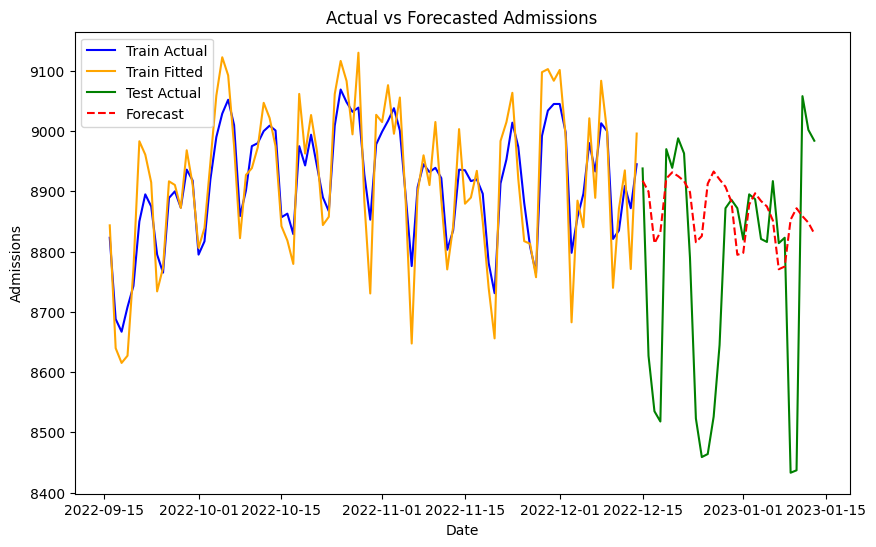

In [3]:
#| hide

# from feature_engine.encoding import OneHotEncoder, MeanEncoder, OrdinalEncoder, StringSimilarityEncoder, DecisionTreeEncoder
# ohe = OneHotEncoder(drop_last=True)
# mean_enc = MeanEncoder()
# ordinal_enc = OrdinalEncoder(encoding_method='ordered')
# string_sim_enc = StringSimilarityEncoder()
# decision_tree_enc = DecisionTreeEncoder(cv=8)

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
te = TargetEncoder(target_type="continuous")

from peshbeen.datasets import load_wales_admissions
wales_admissions = load_wales_admissions()
wales_admissions["day_of_week"] = wales_admissions.index.dayofweek
wales_admissions["month"] = wales_admissions.index.month
# wales_admissions = pd.get_dummies(wales_admissions, columns=["day_of_week", "month"], drop_first=True, dtype=np.float32)
# split the data into train and test sets
train = wales_admissions[:-80]
test = wales_admissions[-80:-50]
cat_variables = ["day_of_week", "month"]
from peshbeen.transformations import rolling_mean, rolling_std
trns = [rolling_mean(window_size=30, shift=1), rolling_std(window_size=30, shift=1)]

arima_mod = arima(target_col="admissions", order=(1, 0, 1), seasonal_order=(0, 0, 1), seasonal_length=7,
      cat_variables=["day_of_week", "month"], lag_transform=trns, categorical_encoder=te
)

arima_mod.fit(train)
arima_mod.predict_in_sample()

trn= arima_mod.forecast(H=30, exog=test.drop(columns=["admissions"]))

## plot actual vs forecasts
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train.index[-90:], train['admissions'][-90:], label='Train Actual', color='blue')
plt.plot(train.index[-90:], arima_mod.fitted_values[-90:], label='Train Fitted', color='orange')
plt.plot(test.index, test['admissions'], label='Test Actual', color='green')
plt.plot(test.index, trn, label='Forecast', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.title('Actual vs Forecasted Admissions')
plt.legend()
plt.show()

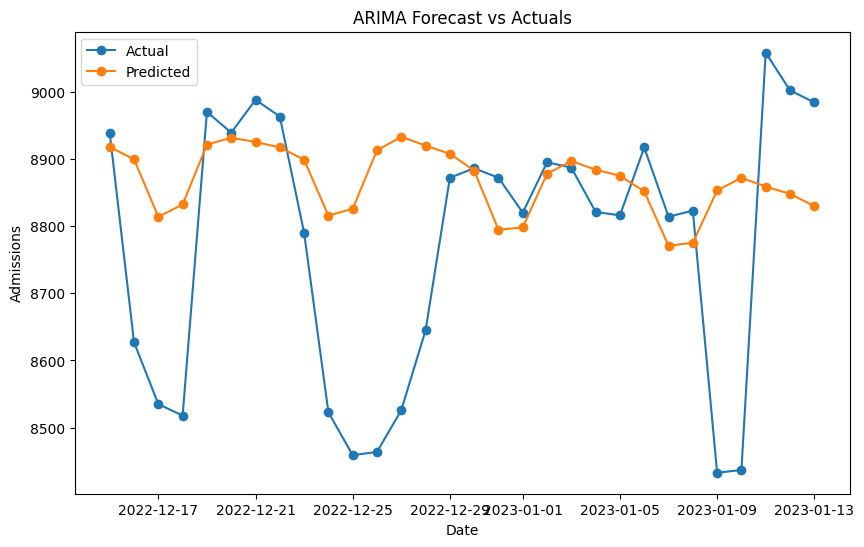

In [4]:
#| hide

from peshbeen.metrics import WMAPE, MAE, RMSE
mtrcs = [WMAPE, MAE, RMSE]
# cv_results = arima_mod.cross_validate(df=train, cv_split=5, test_size=30, metrics=mtrcs, step_size=3, cv_df=True)

# plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(test.index, test["admissions"], label="Actual", marker='o')
plt.plot(test.index, trn, label="Predicted", marker='o')
plt.title("ARIMA Forecast vs Actuals")
plt.xlabel("Date")
plt.ylabel("Admissions")
plt.legend()
plt.show()

In [5]:
#| hide
cvdf = arima_mod.cross_validate(df=train, cv_split=5, test_size=30, metrics=mtrcs, step_size=3)
cvdf.head()

,cutoff,index,split,y_true,y_pred
0,2022-11-03,2022-11-03,fold_1,9038,9031.069542
1,2022-11-03,2022-11-04,fold_1,9001,9017.541128
2,2022-11-03,2022-11-05,fold_1,8891,8930.364468
3,2022-11-03,2022-11-06,fold_1,8776,8920.957316
4,2022-11-03,2022-11-07,fold_1,8907,9004.298275
